In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# 1. Load and Preprocess the CIFAR-10 Dataset
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Validation Set
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")


Loading CIFAR-10 dataset...
Training data shape: (40000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [15]:
def create_cnn_model():
    """Creates a sequential CNN model."""
    model = Sequential([
        # Convolutional Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Convolutional Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Flatten and Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax') # 10 classes for CIFAR-10
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [16]:
# --- Scenario 1: Training WITHOUT Data Augmentation ---
print("\n--- Starting Training: Scenario 1 (Without Data Augmentation) ---")
model_no_aug = create_cnn_model()
model_no_aug.summary()

# Train the model
# Using a portion of training data for validation during training
history_no_aug = model_no_aug.fit(x_train, y_train,
                                  batch_size=64,
                                  epochs=30, # Using fewer epochs for a quicker demonstration
                                  validation_data=(x_val, y_val),
                                  shuffle=True,
                                  verbose=1)



--- Starting Training: Scenario 1 (Without Data Augmentation) ---
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_9 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 16, 16, 32)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 conv2d_11 (Conv2D)          (None, 16, 16, 64)      

2025-07-11 23:12:25.844640: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 491520000 exceeds 10% of free system memory.
2025-07-11 23:12:26.245713: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 491520000 exceeds 10% of free system memory.


Epoch 1/30


2025-07-11 23:12:27.314512: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout_6/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


625/625 [==============================] - 12s 16ms/step - loss: 1.6218 - accuracy: 0.4043 - val_loss: 1.2916 - val_accuracy: 0.5263
Epoch 2/30
625/625 [==============================] - 6s 10ms/step - loss: 1.2079 - accuracy: 0.5676 - val_loss: 1.0127 - val_accuracy: 0.6421
Epoch 3/30
625/625 [==============================] - 6s 9ms/step - loss: 1.0200 - accuracy: 0.6393 - val_loss: 0.9026 - val_accuracy: 0.6832
Epoch 4/30
625/625 [==============================] - 5s 9ms/step - loss: 0.8959 - accuracy: 0.6811 - val_loss: 0.8100 - val_accuracy: 0.7193
Epoch 5/30
625/625 [==============================] - 6s 9ms/step - loss: 0.8150 - accuracy: 0.7132 - val_loss: 0.7814 - val_accuracy: 0.7182
Epoch 6/30
625/625 [==============================] - 5s 8ms/step - loss: 0.7447 - accuracy: 0.7377 - val_loss: 0.7243 - val_accuracy: 0.7502
Epoch 7/30
625/625 [==============================] - 5s 8ms/step - loss: 0.6970 - accuracy: 0.7540 - val_loss: 0.6911 - val_accuracy: 0.7611
Epoch 8/30
625

In [17]:
# Evaluate on the test set
score_no_aug = model_no_aug.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss (No Augmentation): {score_no_aug[0]:.4f}")
print(f"Test Accuracy (No Augmentation): {score_no_aug[1]:.4f}")


Test Loss (No Augmentation): 0.7328
Test Accuracy (No Augmentation): 0.7887


In [18]:
# --- Scenario 2: Training WITH Data Augmentation ---
print("\n--- Starting Training: Scenario 2 (With Data Augmentation) ---")

# Create an ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=45,          # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,      # Randomly shift images horizontally by 20%
    height_shift_range=0.2,     # Randomly shift images vertically by 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    zoom_range=0.20,             # Randomly zoom in on images by 20%
    fill_mode='nearest'
)

# Create and compile the model
model_with_aug = create_cnn_model()



--- Starting Training: Scenario 2 (With Data Augmentation) ---


In [ ]:


train_generator = datagen.flow(x_train, y_train, batch_size=64)


# Train the model using the generator
history_with_aug = model_with_aug.fit(train_generator,
                                      steps_per_epoch=len(x_train) // 64,
                                      epochs=30, # Using the same number of epochs
                                      validation_data=(x_val, y_val),
                                      shuffle=True,
                                      verbose=1)

Epoch 1/30


2025-07-11 23:15:07.959525: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/dropout_9/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


625/625 [==============================] - 22s 33ms/step - loss: 1.8840 - accuracy: 0.3065 - val_loss: 1.5276 - val_accuracy: 0.4367
Epoch 2/30
625/625 [==============================] - 20s 32ms/step - loss: 1.6648 - accuracy: 0.3916 - val_loss: 1.5004 - val_accuracy: 0.4647
Epoch 3/30
625/625 [==============================] - 20s 32ms/step - loss: 1.5565 - accuracy: 0.4359 - val_loss: 1.2868 - val_accuracy: 0.5317
Epoch 4/30
625/625 [==============================] - 20s 32ms/step - loss: 1.4847 - accuracy: 0.4611 - val_loss: 1.3794 - val_accuracy: 0.5016
Epoch 5/30
625/625 [==============================] - 20s 32ms/step - loss: 1.4312 - accuracy: 0.4829 - val_loss: 1.2177 - val_accuracy: 0.5588
Epoch 6/30
625/625 [==============================] - 20s 32ms/step - loss: 1.3820 - accuracy: 0.5007 - val_loss: 1.1288 - val_accuracy: 0.5888
Epoch 7/30
625/625 [==============================] - 20s 32ms/step - loss: 1.3550 - accuracy: 0.5143 - val_loss: 1.2507 - val_accuracy: 0.5508
Epo

In [ ]:
# Evaluate on the test set
score_with_aug = model_with_aug.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss (With Augmentation): {score_with_aug[0]:.4f}")
print(f"Test Accuracy (With Augmentation): {score_with_aug[1]:.4f}")


Test Loss (With Augmentation): 1.0113
Test Accuracy (With Augmentation): 0.6560


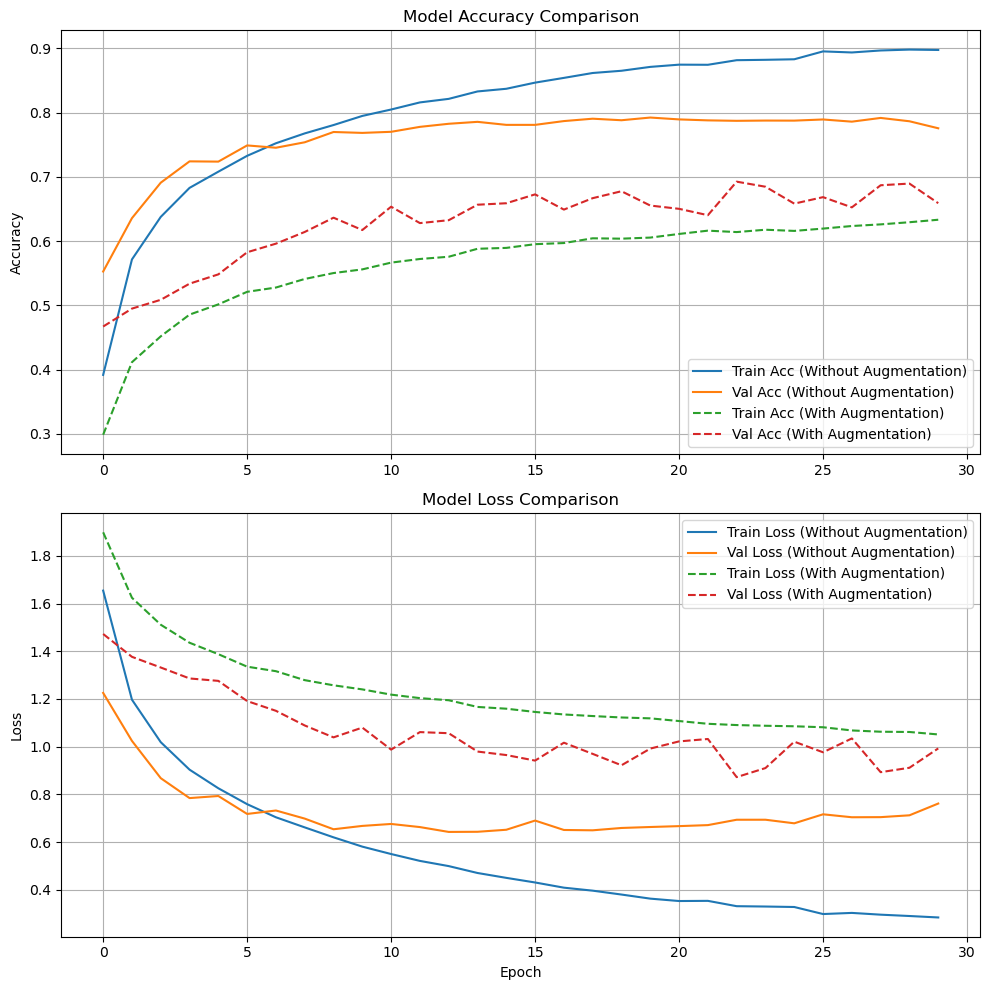

In [ ]:
# 3. Plot and Compare Results
def plot_history(history1, history2, title1="Without Augmentation", title2="With Augmentation"):
    """Plots the training and validation accuracy and loss for two models."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # Plot accuracy
    ax1.plot(history1.history['accuracy'], label=f'Train Acc ({title1})')
    ax1.plot(history1.history['val_accuracy'], label=f'Val Acc ({title1})')
    ax1.plot(history2.history['accuracy'], label=f'Train Acc ({title2})', linestyle='--')
    ax1.plot(history2.history['val_accuracy'], label=f'Val Acc ({title2})', linestyle='--')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy Comparison')
    ax1.legend()
    ax1.grid(True)

    # Plot loss
    ax2.plot(history1.history['loss'], label=f'Train Loss ({title1})')
    ax2.plot(history1.history['val_loss'], label=f'Val Loss ({title1})')
    ax2.plot(history2.history['loss'], label=f'Train Loss ({title2})', linestyle='--')
    ax2.plot(history2.history['val_loss'], label=f'Val Loss ({title2})', linestyle='--')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Model Loss Comparison')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_no_aug, history_with_aug)

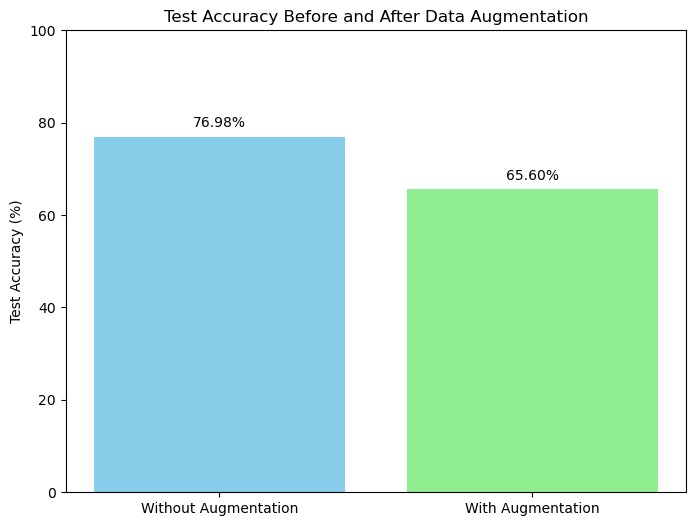

In [ ]:
# Prepare data for the bar chart
labels = ['Without Augmentation', 'With Augmentation']
accuracy_values = [score_no_aug[1] * 100, score_with_aug[1] * 100] # Convert to percentage

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, accuracy_values, color=['skyblue', 'lightgreen'])
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy Before and After Data Augmentation')
plt.ylim(0, 100) # Set the y-axis limit from 0 to 100%
plt.text(labels[0], accuracy_values[0] + 2, f'{accuracy_values[0]:.2f}%', ha='center')
plt.text(labels[1], accuracy_values[1] + 2, f'{accuracy_values[1]:.2f}%', ha='center')
plt.show()